# 🚇 Exploring MTA Ridership Trends After COVID-19

This project analyzes MTA ridership data from 2019–2025 to understand how public transportation usage changed following the COVID-19 pandemic.

By examining travel patterns across different transit systems, the analysis answers two key questions:

1. Which MTA transit mode recovered the fastest after the pandemic?

2. Which transit system shows the biggest difference between weekday and weekend ridership?

The goal of this project is to turn transit data into clear, data-driven insights that highlight how commuting behavior and transportation demand evolved across New York City.

## Getting the Data Ready

Before diving into the analysis, we first load the libraries and ridership datasets that power the project. This step prepares the foundation for exploring how MTA transit patterns changed over time, allowing us to clean the data, uncover trends, and visualize key insights throughout the notebook.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

## Bringing the Ridership Data Into the Analysis

With the setup complete, we can now bring in the ridership data that drives the rest of the analysis. This step introduces the core MTA datasets that will help us track how transit usage changed over time and uncover patterns across different transportation systems.

In [54]:
# Annual ridership by mode (millions of rides)
# Source: MTA.info, NY Governor's Office 2025 Report
df_annual = pd.DataFrame({
    'Year':        [2019,   2020,  2021,  2022,   2023,   2024,   2025],
    'Subway':      [1697.0, 647.0, 778.0, 987.0,  1153.0, 1195.0, 1290.0],
    'Bus':         [674.0,  302.0, 358.0, 399.0,   427.0,  409.0,  458.0],
    'LIRR':        [99.0,    40.0,  49.0,  65.0,    74.0,   74.0,   81.0],
    'Metro-North': [86.9,    30.5,  38.0,  50.0,    65.0,   65.0,   69.0],
})

df_annual.head()

,Year,Subway,Bus,LIRR,Metro-North
0,2019,1697.0,674.0,99.0,86.9
1,2020,647.0,302.0,40.0,30.5
2,2021,778.0,358.0,49.0,38.0
3,2022,987.0,399.0,65.0,50.0
4,2023,1153.0,427.0,74.0,65.0


In [55]:
# Average daily ridership by mode and day type (thousands, 2024)
# Source: MTA 2024 Annual Report
df_wd = pd.DataFrame({
    'Mode':      ['Subway', 'Bus', 'LIRR', 'Metro-North'],
    'Weekday':   [3376,     1290,  222,     195],
    'Saturday':  [2340,      780,  155,     148],
    'Sunday':    [2080,      680,  110,     110],
})

df_wd.head()

,Mode,Weekday,Saturday,Sunday
0,Subway,3376,2340,2080
1,Bus,1290,780,680
2,LIRR,222,155,110
3,Metro-North,195,148,110


## Organizing the Data for Analysis

With the ridership data now loaded, the next step is preparing it for analysis. Here, we clean and structure the datasets so trends, recovery patterns, and transit comparisons can be explored more clearly throughout the project.

In [56]:
# Calculate each year's ridership as % of 2019 (pre-pandemic baseline)
modes = ['Subway', 'Bus', 'LIRR', 'Metro-North']
baseline = df_annual[df_annual['Year'] == 2019][modes].iloc[0]

df_recovery = df_annual[df_annual['Year'] >= 2020].copy()
for mode in modes:
    df_recovery[mode] = (df_recovery[mode] / baseline[mode] * 100).round(1)

df_recovery[['Year'] + modes]

,Year,Subway,Bus,LIRR,Metro-North
1,2020,38.1,44.8,40.4,35.1
2,2021,45.8,53.1,49.5,43.7
3,2022,58.2,59.2,65.7,57.5
4,2023,67.9,63.4,74.7,74.8
5,2024,70.4,60.7,74.7,74.8
6,2025,76.0,68.0,81.8,79.4


In [57]:
# Calculate weekend average and weekday premium
df_wd['Weekend Avg'] = ((df_wd['Saturday'] + df_wd['Sunday']) / 2).round(1)
df_wd['Weekday Premium %'] = ((df_wd['Weekday'] - df_wd['Weekend Avg']) / df_wd['Weekend Avg'] * 100).round(1)

df_wd[['Mode', 'Weekday', 'Weekend Avg', 'Weekday Premium %']]

,Mode,Weekday,Weekend Avg,Weekday Premium %
0,Subway,3376,2210.0,52.8
1,Bus,1290,730.0,76.7
2,LIRR,222,132.5,67.5
3,Metro-North,195,129.0,51.2


## Visualizing Post-Pandemic Transit Recovery

### Q1 - Which MTA Transit Mode Bounced Back the Fastest?

Now that the data has been prepared, we can begin visualizing how different transit systems recovered after COVID-19. These charts help highlight which modes regained riders the quickest and how recovery patterns changed over time.

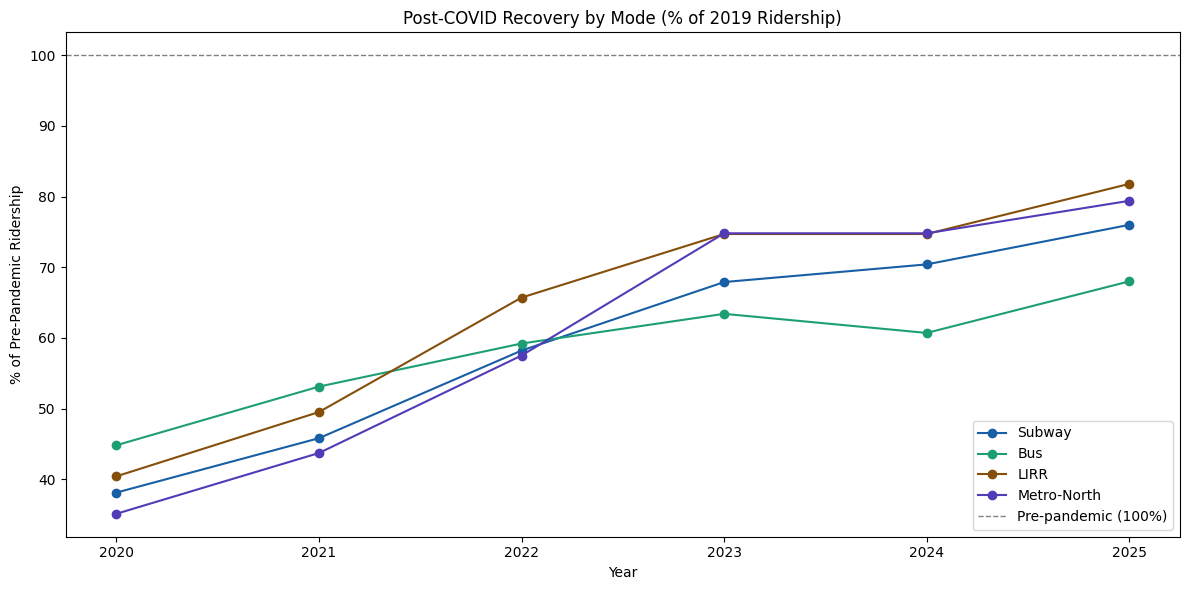

In [58]:
# Line chart: recovery % over time for each mode
colors = {'Subway': '#185FA5', 'Bus': '#1D9E75', 'LIRR': '#854F0B', 'Metro-North': '#533AB7'}

plt.figure(figsize=(12, 6))
for mode in modes:
    plt.plot(df_recovery['Year'], df_recovery[mode], marker='o', label=mode, color=colors[mode])

plt.axhline(100, color='gray', linestyle='--', linewidth=1, label='Pre-pandemic (100%)')
plt.title('Post-COVID Recovery by Mode (% of 2019 Ridership)')
plt.xlabel('Year')
plt.ylabel('% of Pre-Pandemic Ridership')
plt.xticks(df_recovery['Year'])
plt.legend()
plt.tight_layout()
plt.show()

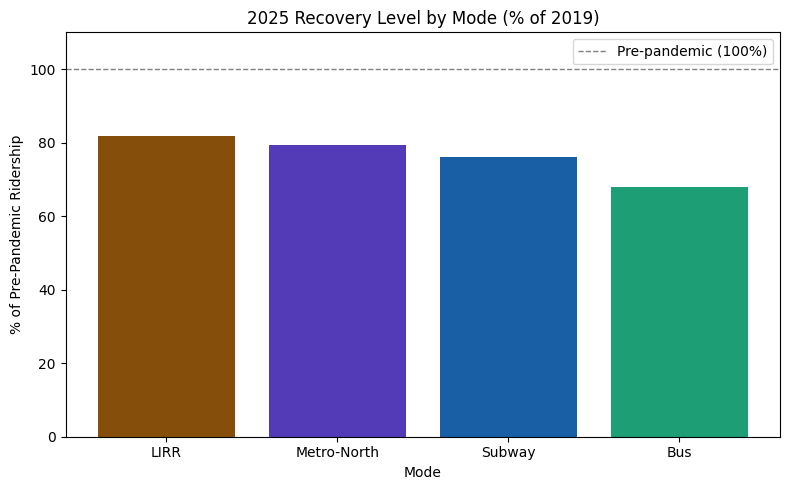

In [59]:
# Bar chart: 2025 recovery level ranked by mode
recovery_2025 = df_recovery[df_recovery['Year'] == 2025][modes].iloc[0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(recovery_2025.index, recovery_2025.values, color=[colors[m] for m in recovery_2025.index])
plt.axhline(100, color='gray', linestyle='--', linewidth=1, label='Pre-pandemic (100%)')
plt.title('2025 Recovery Level by Mode (% of 2019)')
plt.xlabel('Mode')
plt.ylabel('% of Pre-Pandemic Ridership')
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

### Q2 — Which Transit Mode Depends Most on Weekday Commuters?

After exploring post-pandemic recovery trends, the next step is understanding how travel behavior changes throughout the week. In this section, we compare weekday and weekend ridership patterns to identify which transit systems rely most heavily on daily commuters versus more consistent all-week travel.

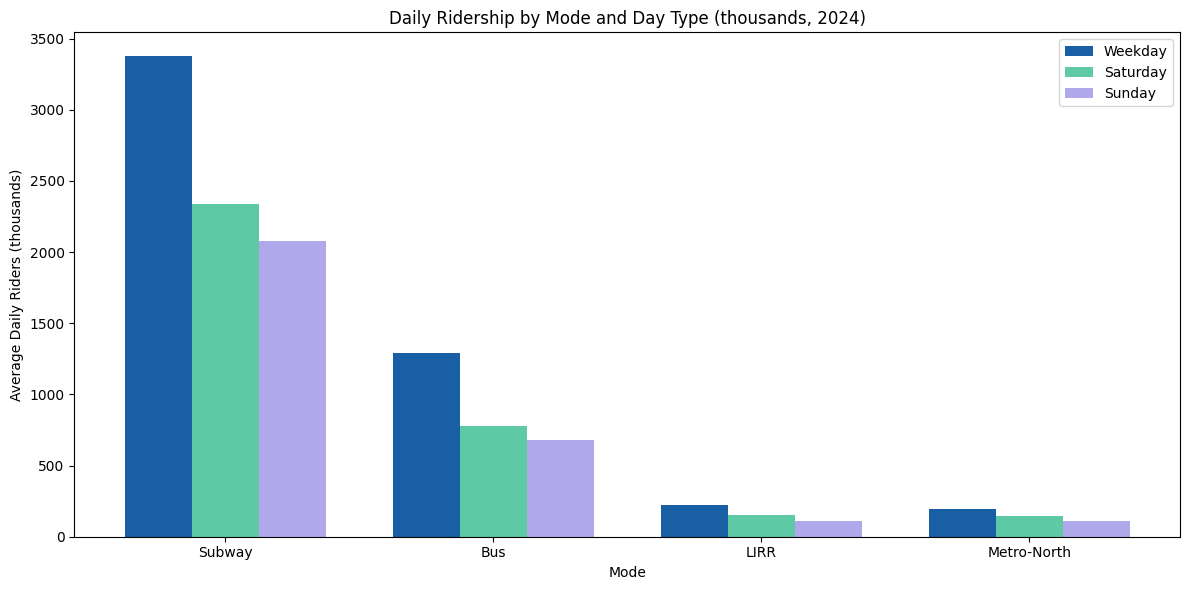

In [60]:
# Grouped bar chart: Weekday, Saturday, Sunday side by side
x = range(len(df_wd))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar([i - width for i in x], df_wd['Weekday'],  width, label='Weekday',  color='#185FA5')
plt.bar([i          for i in x], df_wd['Saturday'], width, label='Saturday', color='#5DCAA5')
plt.bar([i + width  for i in x], df_wd['Sunday'],   width, label='Sunday',   color='#AFA9EC')

plt.title('Daily Ridership by Mode and Day Type (thousands, 2024)')
plt.xlabel('Mode')
plt.ylabel('Average Daily Riders (thousands)')
plt.xticks(x, df_wd['Mode'])
plt.legend()
plt.tight_layout()
plt.show()

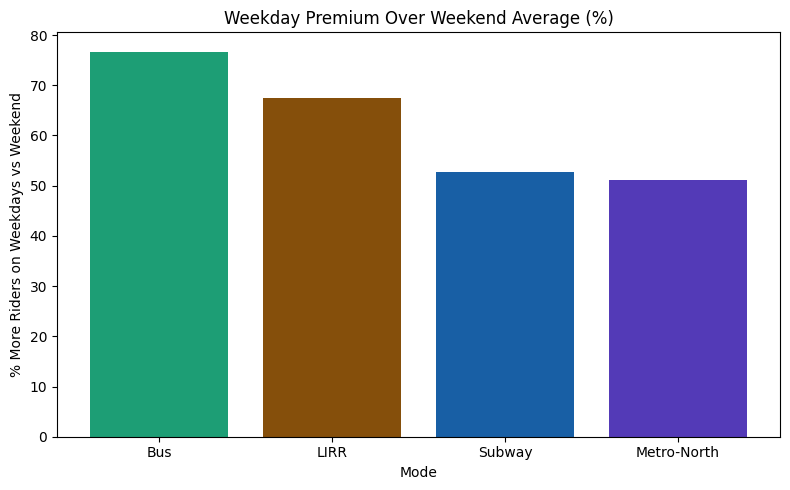

In [61]:
# Bar chart: weekday premium % ranked
df_prem = df_wd.sort_values('Weekday Premium %', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_prem['Mode'], df_prem['Weekday Premium %'], color=[colors[m] for m in df_prem['Mode']])
plt.title('Weekday Premium Over Weekend Average (%)')
plt.xlabel('Mode')
plt.ylabel('% More Riders on Weekdays vs Weekend')
plt.tight_layout()
plt.show()

## Bringing the Key Findings Together

After analyzing ridership recovery trends and weekday commuting patterns, the final step is summarizing the main insights uncovered throughout the project. This section highlights the strongest recovery trends and identifies which transit systems show the biggest differences between weekday and weekend travel behavior.

In [62]:
# Q1: Fastest recovery
winner_q1 = recovery_2025.idxmax()
winner_pct = recovery_2025.max()

# Q2: Most weekday variation
winner_q2 = df_wd.loc[df_wd['Weekday Premium %'].idxmax(), 'Mode']
winner_premium = df_wd['Weekday Premium %'].max()

print("=" * 50)
print("  MTA RIDERSHIP ANALYSIS — FINDINGS")
print("=" * 50)
print()
print(f"  Q1 — Fastest post-COVID recovery:")
print(f"       {winner_q1} ({winner_pct:.1f}% of 2019 levels by 2025)")
print()
print(f"  Q2 — Most weekday vs weekend variation:")
print(f"       {winner_q2} (+{winner_premium:.1f}% more riders on weekdays)")
print("=" * 50)

  MTA RIDERSHIP ANALYSIS — FINDINGS

  Q1 — Fastest post-COVID recovery:
       LIRR (81.8% of 2019 levels by 2025)

  Q2 — Most weekday vs weekend variation:
       Bus (+76.7% more riders on weekdays)


## What the Data Reveals About NYC Transit Recovery

The analysis reveals that recovery across NYC transit systems has not been uniform. While some modes, such as the LIRR, rebounded more quickly toward pre-pandemic ridership levels, others continue to recover at a slower pace. The data also showed that bus ridership experiences the largest gap between weekday and weekend usage, highlighting a stronger dependence on daily commuting patterns. Overall, these findings provide a clearer picture of how travel behavior has shifted since COVID-19 and how different transit systems are adapting to changing commuter needs.